## Aprendizaje Automático III
### Práctica 03: Estimación de densidades

**Equipo de laboratorio:** 12  
**Nombre (miembro 1):** Iván Domínguez Hernández  
**Nombre (miembro 2):** Lucas Miranda López 

### Instrucciones Generales

* **Identificación:** Incluid el **nombre de todos los miembros del equipo de laboratorio al inicio de todos los archivos** entregados.
* **Ejecución:** Entregad este cuaderno de Python con **todas las celdas ejecutadas** de manera secuencial. Aseguraos de que el código se ejecuta sin errores (**Kernel -> Restart & Run All**). Los errores de ejecución pueden ser penalizados.
* **Modularización:** Las funciones deben definirse en un **archivo separado (.py)**, no en el notebook. Incluid en la entrega todos los archivos necesarios para la ejecución.
* **Informe:** El informe será evaluado por su **corrección, claridad, concisión y completitud**.
* **Presentación de resultados:** Utilizad **figuras y tablas** para presentar los resultados e ilustrar las conclusiones.
* **Fuentes y referencias:** se pueden usar materiales del curso y fuentes externas. Las **fuentes deben ser citadas** en formato APA ([Guía APA 7](https://pitt.libguides.com/citationhelp/apa7)). La falta de referencias o el uso de un formato incorrecto serán penalizados.
* **IA Generativa:** Se permite el uso de herramientas de IA (especificando cuales) para realizar consultas y mejorar la redacción del informe. **Está estrictamente prohibido utilizar IA para generar código o texto que se integre de manera literal**** en el cuaderno.

---

### Formato de Entrega

La entrega debe ser un único archivo `.zip` cuyo nombre sea:  
`AA3_2025_2026_P03_<equipo_lab>_<apellido1_1>_<apellido2_1>.zip`  
*(Ejemplo: `AA3_2025_2026_P03_13_munyoz_deLaRosa.zip`)*

**El archivo comprimido debe contener:**
1.  **Este notebook de Python** con las soluciones (código, figuras, tablas y explicaciones). Las derivaciones manuscritas pueden incluirse como imágenes.
2.  **Archivos `.py` y adicionales** necesarios para que la ejecución del cuaderno de Python.
3.  **Archivo PDF** generado desde el notebook (Exportar a HTML -> Imprimir como PDF).

In [1]:
%load_ext autoreload
%autoreload 2

# Ejercicio 1: Estimación de la densidad con Parzen


En este ejercicio analizaremos el uso de **estimadores de densidad basados en kernels (ventanas de Parzen)** y cómo su rendimiento depende de la **dimensión del espacio de datos**.

Supongamos que tenemos un conjunto de datos $x_1,\dots,x_N$ generado a partir de una distribución desconocida $p(x)$.

La estimación de densidad mediante ventanas de Parzen se define como:

$$
\hat p(x) =
\frac{1}{N h^D}
\sum_{n=1}^{N}
K\left(\frac{\|x-x_n\|_2}{h}\right)
$$

donde:

- $K(\cdot)$ es un **kernel** (por ejemplo, gaussiano),
- $h$ es el **ancho de banda**,
- $d$ es la **dimensión de los datos**.

Realice las siguientes tareas: 
1. Implemente el estimador de densidad (fichero `.utils/parzen_density.py`).
2. ¿Cómo seleccionaría $h$?
3. Estudie el error en función de el número de muestras y de la dimensión del espacio de entrada. 

Para ello realizarán dos experimentos: 

i. Fije el número de muestras y aumente la dimensión, ¿cómo evoluciona el error entre la función de densidad original y la estimada?

ii. Fije la dimensión y aumente el número de muestras. ¿Cómo evoluciona el error entre la función de densidad original y la estimada?


Como ayuda dispone de una función que genera datos sintéticos, en la siguiente celda tiene un ejemplo de cómo usarla. 
Para medir el error tiene las siguientes métricas posibles: MSE, KL divergence, JS divergence o total variation.

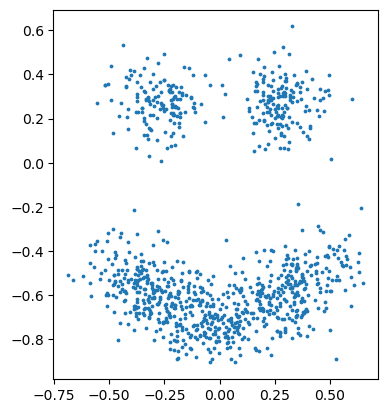

In [2]:
from utils.generate_probability_density_data import generate_density, sample_from_density
dim = 8
num_samples = 1000
random_state = 1000
density = generate_density(dim, random_state=random_state)

X = sample_from_density(density, dim, num_samples, random_state=random_state)

# Visualize the samples (only the first two dimensions for 2D scatter plot)
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.gca().set_aspect("equal")
plt.show()

## 2. Como encontrar $h$ óptimo
- ### 1. Métodos heurísticos (Sheather, 2004):
  
Regla de Silverman la cual viene dada por $$h = \left( \frac{4\hat{\sigma}^5}{3n} \right)^{\frac{1}{5}} \approx 1.06 \hat{\sigma} n^{-1/5}$$ 
Dónde $\hat{\sigma}$ es la desviación estándar de la muestra y $n$ el número de puntos. Este métedo funciona bien siempre y cuando la distribución de nuestros datos conocidos se asemeje lo más posible a una gaussiana.

Para entender de donde viene esta regla tenemos que expresar el error cuadrático Medio integrado Asintótico (AMISE) para un estimador de densidad de kernel, el cual se define como:

$AMISE\{\hat{f}_{h}\} = \frac{1}{nh}R(K) + \frac{h^{4}}{4}\mu_{2}(K)^{2}R(f^{\prime\prime})$

Al minimizar la ecuación de AMISE, se obtiene el valor ideal para el ancho de banda:

$h_{AMISE} = \left[ \frac{R(K)}{\mu_{2}(K)^{2}R(f^{\prime\prime})} \right]^{1/5} n^{-1/5}$

El único término desconocido en nuestra fromula es $R(f^{\prime\prime})$ . Pero con la asunción de normalidad de los datos podemos hayar este término, dando como resultado la formula cerrada inicial.

Por otra parte podemos usar Cross Validation. Para evitar el problema de intentar estimar la probabilidad subyacente de nuestros datos podemos usar subsets de los mismos para realizar validación cruzada en busca de un ancho de banda basado en los propios datos. Para simplificar la codificación usaremos la función de parzen density de sklearn para ejemplificar la busqueda de h, y no tener que implementar fit en nuestra función.


In [3]:
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

n, d = X.shape 

# 1. Estimación inicial del rango de h
# Usamos una escala logarítmica para cubrir varios órdenes de magnitud.
params = {'bandwidth': np.logspace(-2, 2, 30)} 
parzen_density = KernelDensity(kernel='gaussian')

# 3. Búsqueda con Validación Cruzada con 5 folds para encontrar el mejor ancho de banda.
grid = GridSearchCV(parzen_density, params, cv=5, n_jobs=-1) # n_jobs = -1 para procesar paralelamente
grid.fit(X)

print(f"Mejor ancho de banda para 8D: {grid.best_params_['bandwidth']}")

Mejor ancho de banda para 8D: 0.09236708571873861




El parámetro $h$ se debería seleccionar o bien con optimización (1) o bien con validación cruzada (2). 

(1) Encontrar la solución que minimice la log-verosimilitud negativa.

(1.1) El kernel que vamos a usar es gaussiano y de la forma:

$$K(\mu) = \frac{1}{(2\pi)^{D/2}} \exp\left[ -\frac{1}{2} \sum_{i=1}^{D} \mu_i^2 \right]$$

El operador $K(\cdot)$ será proporcional a $e^{-\frac{1}{h^2D}}$ cuando le pasamos $\frac{\mu}{h}$ como parámetro.
Demostración:

$$K\left(\frac{\mu}{h}\right) = \frac{1}{(2\pi)^{D/2}} \exp\left[ -\frac{1}{2} \sum_{i=1}^{D} \frac{\mu_i^2}{h^2} \right] =$$

$$= \frac{1}{(2\pi)^{D/2}} \exp\left[ -\frac{1}{2} \cdot \frac{1}{h^2 D} \cdot \sum_{i=1}^{D} \mu_i^2 \right] =$$

$$= \frac{1}{(2\pi)^{D/2}} e^{-\frac{1}{2}} e^{-\frac{1}{h^2 D}} e^{\sum_{i=1}^{D} \mu_i^2} \propto e^{-\frac{1}{h^2 D}}$$

(1.2) Aprovechando esto, podemos ver que:

$$p(x) \propto \frac{1}{h^D} \sum_{n=1}^{N} e^{-\frac{1}{h^2 D}}$$

Con esto, es fácil plantear el problema de optimización:

$$h^*_{ML} = \arg\max_{h} p(D|h) = \arg\max_{h} \prod_{i=1}^{N} p(x_i | h) =$$

$$= \arg\min_{h} -\log\left[ \frac{1}{h^D} \prod_{i=1}^{N} e^{-\frac{1}{h^2D}} \right] =$$

$$= \arg\min_{h} \left[ D\log h + \sum_{i=1}^{N} \frac{1}{h^2D} \right] =$$

$$= \arg\min_{h} \left[ D\log h + \frac{N}{h^2D} \right]$$

$$\nabla_h \left[ D\log h + \frac{N}{Dh^2} \right] = \frac{D}{h} + \frac{-2hDN}{h^4D^2} |_{h = h^*_{ML}} = 0 \text{ (condición de óptimo local)}$$

$$\iff \frac{D}{h^*_{ML}} = \frac{2h^*_{ML}DN}{(h^*_{ML})^4D^2} \iff D = \frac{2N}{(h^*_{ML})^2D^2} \iff h^*_{ML} = \sqrt{\frac{2N}{D^2}}$$


Con esto, se debería comprobar que cuando crece la dimensión, para un mismo número de muestras, debería crecer la cantidad de espacio vacío (en general) y por tanto el valor de las métricas que tengan que ver con las distancias o las divergencias:

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from utils.generate_probability_density_data import generate_density, sample_from_density
from models import parzen_density
from utils import compute_metrics, plot_metrics

# fixed number of samples
N = 2000

dims = np.arange(2, 11, 2, dtype=int)  # dimensions from 2 to 10 with step of 2

mse_list = []
kl_list = []
js_list = []
tv_list = []

for d in dims:
    
    h = np.sqrt((2*N)/(d**2))

    density = generate_density(d, random_state=random_state)

    X = sample_from_density(density, d, N)

    est_density = parzen_density(X, h)

    mse, kl, js, tv = compute_metrics(density, est_density, sample_from_density, dim=d, n_eval= 20000)

    mse_list.append(mse)
    kl_list.append(kl)
    js_list.append(js)
    tv_list.append(tv)

plot_metrics(dims, mse_list, kl_list, js_list, tv_list)

TypeError: 'module' object is not callable

Efectivamente, esto se comprueba. Cuanto mayor es la dimensión, mayor es la cantidad de espacio vacío y, por tanto, mayores son estas métricas de distancia y divergencia. 

No debería pasar lo mismo al aumentar las muestras. Lo normal al hacer eso con una dimensión fija es que el espacio se vaya llenando. Tal vez podamos notar que la forma de esta curva no es monótona decreciente por culpa del efecto de la aleatoriedad al crear muestras, pero, en general, cuando $N$ crezca lo suficiente, el espacio se llenerá y las métricas disminuirán (si miden promedios, como es el caso de las 4 que se prueban). 

Atendiendo a la forma de $h_{ML}^*$: $$h_{ML}^* = \sqrt{\frac{2N}{D^2}}$$ 

- Al aumentar la dimensión $D$, $h_{ML}^*$ disminuye.

Por el contrario:

- Al aumentar el número de muestras $N$, $h_{ML}^*$ aumenta.



c. Con un número de muestra fija, si aumenta la dimensión ¿$h$ óptimo crece o decrece?

d. Con una dimensión fija, al aumentar el número de muestra  ¿$h$ óptimo crece o decrece?

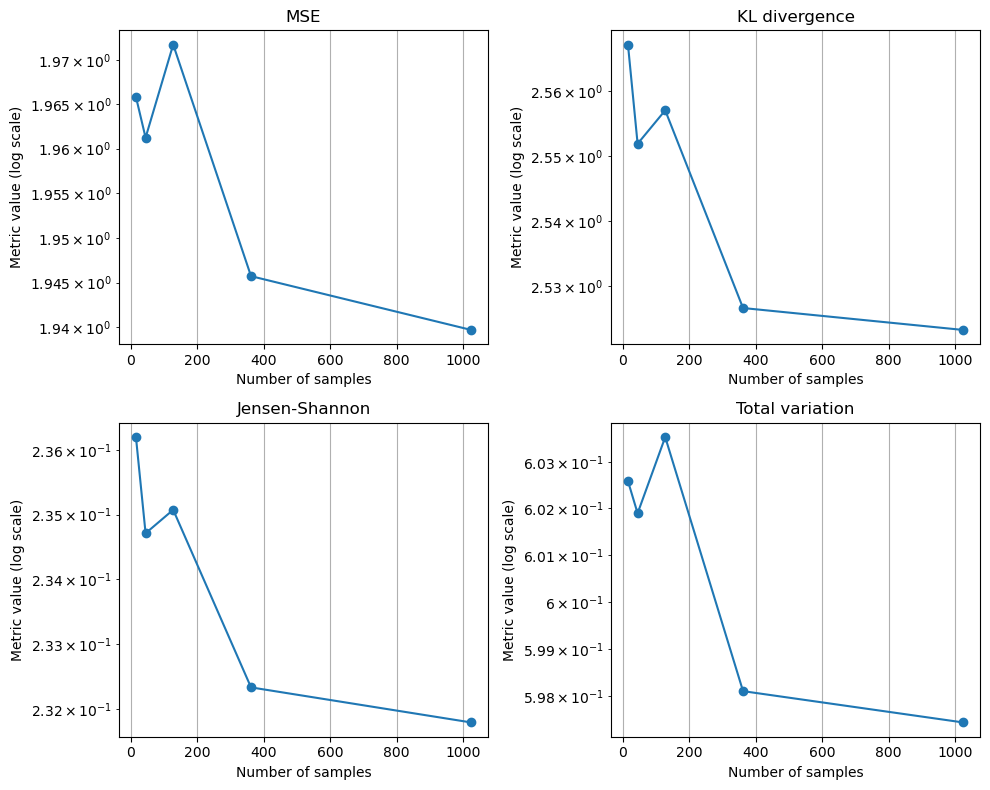

In [ ]:
# dimensión fija y aumentamos muestras
dim = 2
num_samples_list = np.logspace(2, 5, num=5, base=4, dtype=int)  

mse_list = []
kl_list = []
js_list = []    
tv_list = []

for num_samples in num_samples_list:
    
    h = np.sqrt((2*num_samples)/(dim**2))
    
    density = generate_density(dim, random_state=random_state)

    X = sample_from_density(density, dim, num_samples)

    est_density = parzen_density(X, h)

    mse, kl, js, tv = compute_metrics(density, est_density,sample_from_true_density=sample_from_density, dim=dim, n_eval= 20000)

    mse_list.append(mse)
    kl_list.append(kl)
    js_list.append(js)
    tv_list.append(tv)

plot_metrics(num_samples_list, mse_list, kl_list, js_list, tv_list, samples=True)

Con esto podemos comprobar que, efectivamente, cuando $N$ crece lo suficiente, en general, las métricas disminuyen, pues tienden a rellenar el espacio vacío en el plano ($dim=2$). 

## Ejercicio 2
¿Como utilizarías la estimación de densidad para resolver el siguiente problema de regresión?

Pista: 

Resolver un problema de regresión es equivalente a en estimar la **densidad conjunta** de las variables de entrada y salida:

$P(X, Y)$

utilizando un estimador de densidad como **Parzen windows (KDE)**.  


Una vez estimada la densidad conjunta, podemos obtener la **densidad condicional**:

$P(Y \mid X) = \frac{P(X,Y)}{P(X)}$

A partir de esta distribución condicional podemos construir una función de regresión.

Existen varias estrategias posibles:

#### 1. Estimación por máxima probabilidad (MAP).  (0-1 loss)

Se predice el valor de $y$ que maximiza la probabilidad conjunta:

$f(x) = \arg\max_y P(x, y)$

Esto consiste en buscar el valor de $y$ que hace más probable el par $(x,y)$ según la densidad estimada.

#### 2. Regresión por esperanza condicional (MSE)

Otra opción es usar el valor esperado de $Y$ dado $X$:

$f(x) = \mathbb{E}[Y \mid X]$

En la práctica se aproxima evaluando la densidad conjunta en distintos valores de $y$ y calculando la media ponderada.

#### 3. Mediana condicional (MAE)

$m : X \longrightarrow Y$ se calcula como el valor tal que $P(Y \leq m(x) \mid X=x) = 0.5$


Implementa al menos una de ella. 

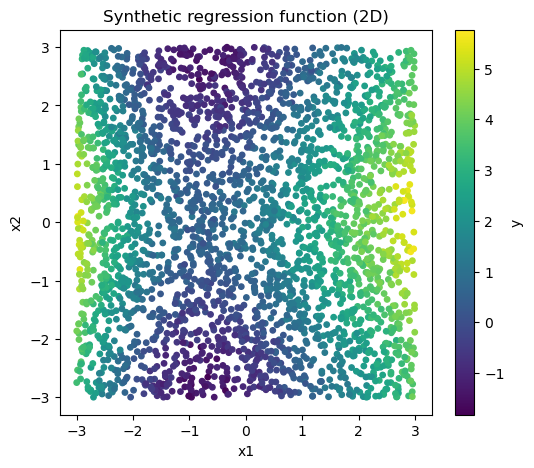

In [ ]:
# Ejemplo de código para generar y visualizar datos de regresión en 2D utilizando Python y Matplotlib.
import matplotlib.pyplot as plt
from utils import generate_regression_data
# ---- generate 2D data ----
X, y = generate_regression_data(
    n_samples=3000,
    dim=2,
    noise=0.2,
    random_state=0
)

# ---- plot ----
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", s=15)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic regression function (2D)")
plt.colorbar(label="y")
plt.show()

In [ ]:
from models import DensityRegression
from sklearn.metrics import r2_score, mean_squared_error

density_regressor = DensityRegression()
density_regressor.fit(X, y)

y_pred = density_regressor.predict(X)
print("R^2 Score:", r2_score(y, y_pred))
print("Mean Squared Error:", mean_squared_error(y, y_pred))

NameError: name 'preds' is not defined

# Ejercicio 3


Responda razonadamente: ¿Cuál es la ventaja de usar distribuciones de la familia exponencial en un
modelo de mezcla de distribuciones para la estimación de parámetros
mediante el algoritmo de *expectation-maximization* (EM)?


**Pista:** Supongamos que el modelo de mezcla pertenece a la familia exponencial y tiene la forma:

$$
p(x_n \mid z_n = k, \eta_k) = h(x_n)\exp\left(\eta_k^T T(x_n) - A(\eta_k)\right), 
\quad k = 1,\dots,K
$$

donde:

- $\eta_k$ son los **parámetros naturales** de la componente $k$  
- $T(x_n)$ son los **estadísticos suficientes**  
- $A(\eta_k)$ es el **logaritmo de la función de partición**  
- $h(x_n)$ es la **medida base**

Supongamos además un **prior categórico** sobre la variable latente:

$$
p(z_n = k \mid \pi) = \pi_k, \qquad \sum_{k=1}^K \pi_k = 1
$$

Calcula la verosimilitud  y partir de este modelo:

1. Calcula el **paso E** del algoritmo EM, obteniendo las responsabilidades

$$
\gamma_{nk} = p(z_n = k \mid x_n, \eta^{old}, \pi^{old})
$$

2. Calcula el **paso M**, maximizando la esperanza de la log-verosimilitud completa para obtener las actualizaciones de:

- $\pi_k$
- $\eta_k$

# 1.2 Ilustra la respuesta con un ejemplo usando modelos de mezcla de gaussianas

$$p(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x|\mu_k, \sigma_k^2) $$


## Ayuda, explicación de EM

El algoritmo EM (Expectation-Maximization) es un método iterativo de optimización utilizado para estimar parámetros de modelos probabilísticos cuando existen variables ocultas, datos incompletos o información no observable directamente.

Se utiliza con mucha frecuencia en contextos como:
	•	Mezclas de gaussianas (Gaussian Mixture Models, GMM)
	•	Modelos con datos faltantes
	•	Clustering probabilístico
	•	Modelos ocultos de Markov
	•	Problemas de inferencia estadística con variables latentes


1. Idea principal del algoritmo

Supongamos que tenemos un conjunto de datos observados:

$$
X = \{x_1, x_2, \dots, x_N\}
$$

Queremos estimar unos parámetros $\theta$ de un modelo probabilístico.

Por ejemplo, si asumimos que todos los datos provienen de una única distribución Gaussiana, los parámetros serían:

$$
\theta = (\mu, \sigma)
$$

donde:

- $\mu$ es la media
- $\sigma$ es la desviación típica

En ese caso no falta ninguna información oculta, porque todas las observaciones pertenecen a la misma distribución.

Si toda la información fuese observable, podríamos maximizar directamente la log-verosimilitud:

$$
\log p(X \mid \theta)
$$

Sin embargo, el algoritmo EM aparece cuando parte de la información no es observable.

Por ejemplo, supongamos ahora que los datos no provienen de una sola gaussiana, sino de una mezcla de dos gaussianas.

Imaginemos las siguientes muestras:

$$
X = \{1.1, 0.9, 1.3, 5.2, 4.8, 5.1\}
$$

A simple vista parece que existen dos grupos:

- Un grupo cerca de $1$
- Un grupo cerca de $5$

Podríamos modelar esos datos como una mezcla de dos gaussianas:

$$
p(x) =
\pi_1 \mathcal{N}(x \mid \mu_1, \sigma_1^2)
+
\pi_2 \mathcal{N}(x \mid \mu_2, \sigma_2^2)
$$

Ahora los parámetros son:

$$
\theta = (\pi_1, \pi_2, \mu_1, \mu_2, \sigma_1, \sigma_2)
$$

Pero aparece un problema: no sabemos qué observaciones pertenecen a cada gaussiana.

Por ejemplo, no sabemos si:

$$
x_i = 1.1
$$

proviene de la primera gaussiana o de la segunda.

Para representar esa información introducimos una variable oculta:
$$
z_i \in \{1,2\}
$$

donde:

- $z_i = 1$ significa que $x_i$ pertenece a la primera gaussiana
- $z_i = 2$ significa que $x_i$ pertenece a la segunda gaussiana

Si conociéramos todas esas etiquetas ocultas:

$$
Z = \{1,1,1,2,2,2\}
$$

entonces sería muy fácil estimar los parámetros de cada gaussiana por separado.

Pero como no conocemos esas etiquetas, necesitamos estimarlas. Ese es precisamente el objetivo del algoritmo EM.
Sin embargo, en muchos problemas existe una parte de la información que no observamos. Denotaremos esa información oculta por:

$Z$

Por tanto, el modelo completo depende de:

$(X, Z)$

El problema es que maximizar directamente:

$\log p(X \mid \theta)$

puede ser muy difícil.

La idea del algoritmo EM consiste en:
1.	Estimar probabilísticamente las variables ocultas $Z$.
2.	Utilizar esa estimación para recalcular los parámetros del modelo.
3.	Repetir el proceso hasta converger.

⸻


2. Función objetivo

Queremos maximizar la verosimilitud de los datos observados:

$p(X \mid \theta)$

O equivalentemente, la log-verosimilitud:

$\ell(\theta) = \log p(X \mid \theta)$

Cuando existen variables ocultas Z, podemos escribir:

$p(X \mid \theta) = \sum_Z p(X, Z \mid \theta)$

Por tanto:

$\log p(X \mid \theta) = \log \sum_Z p(X, Z \mid \theta)$

El problema es que el logaritmo de una suma suele ser difícil de optimizar.

EM resuelve esta dificultad utilizando una aproximación iterativa basada en esperanza matemática.

⸻

3. Pasos del algoritmo EM

El algoritmo alterna entre dos pasos:

Paso E (Expectation)

En este paso calculamos la distribución de probabilidad de las variables ocultas usando los parámetros actuales.

Es decir, calculamos: $p(Z \mid X, \theta^{(t)})$

Aquí:
-	$\theta^{(t)}$ son los parámetros actuales en la iteración t
-	$Z$ son las variables ocultas
-	$X$ son los datos observados

Con esto obtenemos una *asignación blanda* de cada observación a las posibles clases o componentes.

Por ejemplo, en una mezcla de gaussianas, para cada punto calculamos la probabilidad de pertenecer a cada gaussiana.

⸻

Paso M (Maximization)

En este paso actualizamos los parámetros del modelo maximizando la esperanza de la log-verosimilitud completa.

Definimos:

$Q(\theta, \theta^{(t)}) = \mathbb{E}_{Z \mid X, \theta^{(t)}}[\log p(X, Z \mid \theta)]$

Y buscamos:

$\theta^{(t+1)} = \arg\max_\theta Q(\theta, \theta^{(t)})$

Es decir:
1.	Suponemos conocidas las probabilidades de las variables ocultas.
2.	Recalculamos los parámetros que mejor explican los datos.

⸻

5. ¿Por qué funciona?

EM funciona porque en cada iteración garantiza que la log-verosimilitud no disminuye.

Es decir:

$$
\log p(X \mid \theta^{(t+1)}) \geq \log p(X \mid \theta^{(t)})
$$

Esto significa que cada paso mejora o mantiene la calidad del ajuste.

La justificación matemática se basa en tres ideas fundamentales:
1.	La desigualdad de Jensen.
2.	La construcción de una cota inferior de la log-verosimilitud.
3.	La maximización alternada de dicha cota.

⸻

5.1 Dificultad original

Queremos maximizar:

$$
\log p(X \mid \theta)
$$

Pero cuando existen variables ocultas $Z$:

$$
p(X \mid \theta) = \sum_Z p(X, Z \mid \theta)
$$

por lo que:

$$
\log p(X \mid \theta) = \log \sum_Z p(X, Z \mid \theta)
$$

El problema es que el logaritmo está aplicado a una suma, y eso hace muy difícil derivar y maximizar directamente.

⸻

5.2 Introducción de una distribución auxiliar

EM introduce una distribución auxiliar $q(Z)$, que representa una estimación probabilística de las variables ocultas.

Podemos escribir:

$$
\log p(X \mid \theta)
=
\log \sum_Z q(Z) \frac{p(X, Z \mid \theta)}{q(Z)}
$$

Esta expresión es válida porque simplemente hemos multiplicado y dividido por $q(Z)$.

⸻

5.3 Aplicación de la desigualdad de Jensen

La desigualdad de Jensen dice que, como el logaritmo es una función cóncava:

$$
\log \mathbb{E}[Y] \geq \mathbb{E}[\log Y]
$$

Aplicándola a la expresión anterior sobre la esperenza de $Z$:

$$
\log p(X \mid \theta)
\geq
\sum_Z q(Z)
\log
\left(
\frac{p(X, Z \mid \theta)}{q(Z)}
\right)
$$

Esto nos da una cota inferior de la log-verosimilitud.

Definimos entonces:

$$
\mathcal{L}(q, \theta)
=
\sum_Z q(Z)
\log
\left(
\frac{p(X, Z \mid \theta)}{q(Z)}
\right)
$$

Y por tanto:

$$
\log p(X \mid \theta) \geq \mathcal{L}(q, \theta)
$$
A la expresión de la derecha la llamamos ELBO (Evidence Lower Bound) o Límite Inferior de la Evidencia.
El algoritmo EM alterna entre optimizar $\mathcal{L}(q, \theta)$ con respecto a $q$ y con respecto a $\theta$.
⸻

5.4 Relación con la divergencia KL

Ahora vemos  que 

$$
\log p(X \mid \theta)
=
\mathcal{L}(q, \theta)
+
D_{KL}(q(Z) \parallel p(Z \mid X, \theta))
$$

Como la divergencia KL siempre es no negativa:

$$
D_{KL}(q(Z) \parallel p(Z \mid X, \theta)) \geq 0
$$

obtenemos automáticamente:

$$
\log p(X \mid \theta) \geq \mathcal{L}(q, \theta)
$$

La igualdad se cumple cuando:

$$
q(Z) = p(Z \mid X, \theta)
$$

Esta es exactamente la razón por la que en el paso E elegimos:

$$
q(Z) = p(Z \mid X, \theta^{(t)})
$$

⸻

5.5 Cómo se usan estas ideas en EM
1.	La log-verosimilitud original es difícil de maximizar directamente.
2.	Se construye una cota inferior más sencilla usando Jensen.
3.	En el paso E se hace que esa cota toque exactamente a la función original.
4.	En el paso M se maximiza la cota respecto a los parámetros.
5.	Al aumentar la cota, también aumenta la log-verosimilitud.

Por eso EM nunca empeora la solución y converge hacia un óptimo local.

⸻

1. Interpretación intuitiva

EM puede entenderse como un procedimiento de refinamiento iterativo:
1.	Adivinamos inicialmente los parámetros.
2.	Con esos parámetros, estimamos qué variables ocultas serían más probables.
3.	Usamos esa estimación para recalcular mejores parámetros.
4.	Repetimos el proceso.

Poco a poco, el modelo se vuelve más consistente con los datos.

⸻

# 7. Otro ejemplo: lanzamiento de monedas

Supongamos que tenemos dos monedas:

- Moneda A, con probabilidad de cara $\theta_A$
- Moneda B, con probabilidad de cara $\theta_B$

Realizamos varios experimentos. En cada experimento se elige una de las dos monedas y se lanza varias veces.

Por ejemplo:

| Experimento | Resultado |
|------------|------------|
| 1 | H T H H H |
| 2 | T T T H T |
| 3 | H H H H T |
| 4 | T T H T T |

donde:

- $H$ significa cara (Heads)
- $T$ significa cruz (Tails)

Queremos estimar:

$$
\theta = (\theta_A, \theta_B)
$$

El problema es que no sabemos qué moneda se utilizó en cada experimento.

Introducimos entonces una variable oculta:

$$
z_i \in \{A, B\}
$$

donde:

- $z_i = A$ significa que el experimento $i$ se realizó con la moneda A
- $z_i = B$ significa que el experimento $i$ se realizó con la moneda B

---

## Paso E

Calculamos la probabilidad de que cada experimento haya sido generado por cada moneda.

Por ejemplo, para el experimento $i$:

$$
\gamma_{iA} = p(z_i = A \mid x_i)
$$

y:

$$
\gamma_{iB} = p(z_i = B \mid x_i)
$$

Usando Bayes:

$$
\gamma_{iA}
=
\frac{
p(x_i \mid \theta_A) p(z_i = A)
}{
p(x_i \mid \theta_A) p(z_i = A)
+
p(x_i \mid \theta_B) p(z_i = B)
}
$$

y:

$$
\gamma_{iB} = 1 - \gamma_{iA}
$$

Estas responsabilidades indican cuánto explica cada moneda los resultados observados.

---

## Paso M

Usamos esas responsabilidades para actualizar las probabilidades de cara de cada moneda.

Para la moneda A:

$$
\theta_A
=
\frac{
\sum_{i=1}^{N} \gamma_{iA} \cdot (\text{número de caras en } x_i)
}{
\sum_{i=1}^{N} \gamma_{iA} \cdot (\text{número total de lanzamientos en } x_i)
}
$$

Para la moneda B:

$$
\theta_B
=
\frac{
\sum_{i=1}^{N} \gamma_{iB} \cdot (\text{número de caras en } x_i)
}{
\sum_{i=1}^{N} \gamma_{iB} \cdot (\text{número total de lanzamientos en } x_i)
}
$$

---

La idea es la misma que en mezclas de gaussianas:

1. En el paso E estimamos probabilísticamente qué moneda generó cada experimento (a qué gaussiana pertenece cada $x_i$).
2. En el paso M recalculamos los parámetros de cada moneda.
3. Repetimos hasta convergencia.

⸻

8. Criterio de parada

El algoritmo suele detenerse cuando ocurre alguna de estas condiciones:
•	La log-verosimilitud cambia muy poco entre iteraciones.
•	Los parámetros apenas cambian.
•	Se alcanza un número máximo de iteraciones.


⸻

1. Ventajas del algoritmo EM
	•	Es conceptualmente sencillo.
	•	Permite tratar variables ocultas.
	•	Garantiza que la verosimilitud no empeora.
	•	En muchos modelos produce fórmulas cerradas para actualizar parámetros.
	•	Es muy usado en clustering probabilístico.

⸻

10. Desventajas del algoritmo EM
	•	Puede converger a máximos locales.
	•	Depende mucho de la inicialización.
	•	Puede ser lento.
	•	No garantiza encontrar la solución global.
	•	En alta dimensión puede ser computacionalmente costoso.

⸻
11. Pseudocódigo del algoritmo

Inicializar parámetros θ

Repetir hasta convergencia:

    Paso E:
        Calcular p(Z | X, θ)

    Paso M:
        Actualizar θ maximizando:
        E[log p(X, Z | θ)]

Fin



## Solución ejercicio 3

TODO

### Ejercicio 4: Relación con modelos de mezcla

Los estimadores de densidad basados en ventanas de Parzen pueden interpretarse como un caso particular de **modelo de mezcla**, donde cada muestra genera un componente del modelo.

En particular, el estimador de Parzen puede escribirse como

$$
\hat p(x) =
\frac{1}{N}\sum_{n=1}^{N}
\frac{1}{h^D}
K\left(\frac{\|x-x_n\|_2}{h}\right)
$$

lo cual puede interpretarse como un **modelo de mezcla con $N$ componentes**, donde:

- cada componente está centrado en un dato $x_n$,
- todos los componentes tienen el mismo ancho de banda $h$,
- y los pesos de mezcla son iguales.

1. Explique por qué el estimador de Parzen puede interpretarse como un **modelo de mezcla de distribuciones**.

2. Compare esta formulación con un **modelo de mezcla de gaussianas (GMM)** aprendido a partir de los datos.  
   ¿Cuál es la diferencia entre ambos enfoques en términos de:

   - número de componentes
   - parámetros aprendidos
   - flexibilidad del modelo?




Solución: 



### Ejercicio 5: Verosimilitud no acotada en modelos de mezcla

En los **modelos de mezcla de gaussianas**, los parámetros del modelo se estiman normalmente mediante **máxima verosimilitud**, por ejemplo utilizando el algoritmo EM.

Sin embargo, la función de verosimilitud de un modelo de mezcla **no está acotada superiormente**. En particular, si no se impone ninguna restricción sobre las varianzas de las componentes, puede ocurrir el siguiente fenómeno:

- una componente gaussiana puede **colapsar sobre un único punto de la muestra**,  
- haciendo que su varianza tienda a cero,
- lo que provoca que la densidad en ese punto tienda a infinito.

Como consecuencia, la **verosimilitud del modelo puede hacerse arbitrariamente grande**, lo que produce soluciones degeneradas.

1. Explique por qué una gaussiana cuya varianza tiende a cero alrededor de un punto de la muestra produce una verosimilitud arbitrariamente grande.

2. Realice un pequeño experimento con un **modelo de mezcla de gaussianas**, mostrando cómo una componente puede concentrarse alrededor de uno o pocos puntos.

3. Discuta qué estrategias se utilizan en la práctica para evitar este problema, por ejemplo:

- regularización de las covarianzas
- límites inferiores en la varianza
- priors bayesianos
- inicialización adecuada del algoritmo EM

Solución

### Fuentes y referencias:
- Sheather, S. J. (2004). Density estimation. Statistical Science, 19(4), 588–597. https://doi.org/10.1214/088342304000000297